In [1]:
# outlier detect.
# box plot 
# IQR 


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

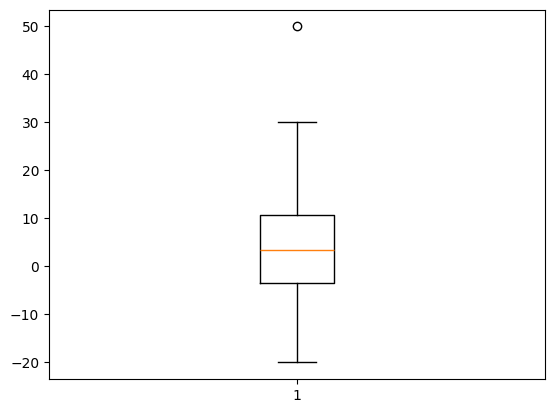

In [36]:
fig, ax = plt.subplots()
ax.boxplot(np.array([-20, -10, -3-2,1,2,5,7, 12, 50, 30]))
plt.show()

In [29]:
# outliers 
# IQR # Quirtile # Quartile : Q1, Q2, Q3, Q4
# percentile : 1 99.99
np.quantile(np.array([-20,-10, -3-2,1,2,5,7, 12, 50, 30]), 0.75)
# np.percentile()

np.float64(10.75)

In [61]:
# IQR = Q3 - Q1 
arr = np.array([1,2,5,7, 12, 50, 30, 100, 100000])
Q1 = np.quantile(arr, 0.25) # 25%
Q3 = np.quantile(arr, 0.75) # 75%

In [62]:
Q1, Q3

(np.float64(5.0), np.float64(50.0))

In [63]:
IQR = Q3 - Q1

In [64]:
IQR

np.float64(45.0)

In [65]:
# lower bound
# upper bound
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [66]:
lower, upper

(np.float64(-62.5), np.float64(117.5))

In [71]:
# data < lower | data > upper 
arr[((arr<lower) | (arr > upper))] = 0

In [72]:
arr

array([  1,   2,   5,   7,  12,  50,  30, 100,   0])

In [73]:
df = pd.read_csv('../../data/IRIS.csv')

In [74]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [95]:
range(1, len(df.columns[:-1])+1)

range(1, 5)

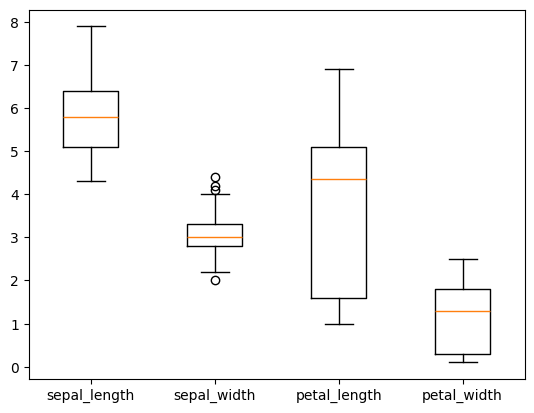

In [99]:
plt.boxplot([df['sepal_length'], df['sepal_width'], df['petal_length'], df['petal_width']])
plt.xticks(ticks = range(1, len(df.columns)), labels=df.columns[:-1])

plt.show()

In [100]:
# df['sepal_width']

0      3.5
1      3.0
2      3.2
3      3.1
4      3.6
      ... 
145    3.0
146    2.5
147    3.0
148    3.4
149    3.0
Name: sepal_width, Length: 150, dtype: float64

In [101]:
IQR = df['sepal_width'].quantile(0.75) - df['sepal_width'].quantile(0.25)

In [103]:
upper, lower = df['sepal_width'].quantile(0.75) + 1.5* IQR, df['sepal_width'].quantile(0.25) - 1.5 * IQR

In [104]:
upper, lower

(np.float64(4.05), np.float64(2.05))

In [107]:
data = df[~((df['sepal_width']< lower) | (df['sepal_width']> upper))]

In [108]:
data.shape, df.shape

((146, 5), (150, 5))

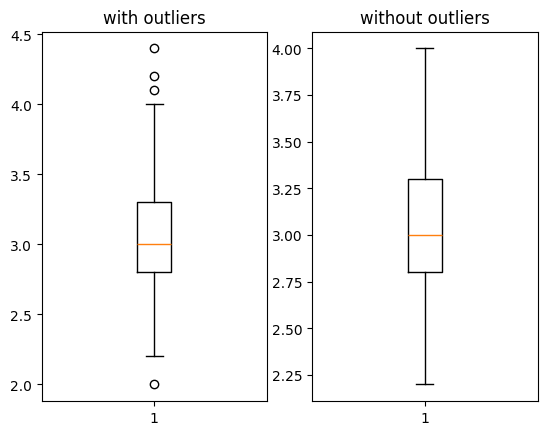

In [116]:
fig, ax = plt.subplots(1,2)
ax[0].boxplot(df['sepal_width'])
ax[0].set_title('with outliers')


ax[1].boxplot(data['sepal_width'])
ax[1].set_title('without outliers')
plt.show()